In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

df = pd.read_pickle('../data/preprocessed/train_data_lgbm.pkl')
movies_features = pd.read_pickle('../data/preprocessed/movies_features_lgbm.pkl')

In [2]:
# Specify that IDs are categorical features, not continuous numerical values.
# This is critical so the model doesn't assume user #100 is "twice as large" as user #50.
df['userId'] = df['userId'].astype('category')
df['movieId'] = df['movieId'].astype('category')

# Split data into features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

In [3]:
# Split data into training and validation sets (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop IDs to force content learning
X_train_content = X_train.drop(columns=['movieId'])
X_val_content = X_val.drop(columns=['movieId'])

In [4]:
# Create LightGBM internal dataset structures
train_data = lgb.Dataset(X_train_content, label=y_train)
val_data = lgb.Dataset(X_val_content, label=y_val, reference=train_data)

# Set model parameters
params = {
    'objective': 'binary',        # We are classifying (1 - will like, 0 - won't)
    'metric': 'auc',              # AUC is excellent for ranking/recommendation tasks
    'learning_rate': 0.05,        # Learning rate (classic starting point)
    'num_leaves': 31,             # Maximum number of leaves in one tree
    'max_depth': -1,              # No limit on tree depth
    'min_data_in_leaf': 20,       # Protection against overfitting
    'feature_fraction': 0.8,      # Use 80% of features for each tree
    'n_jobs': -1,                 # Use all available CPU cores
    'verbose': -1                 # Disable unnecessary log spam
}

# Start the training process
print("Starting LightGBM training...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,                  # Maximum number of boosting iterations
    valid_sets=[train_data, val_data],     # Monitoring performance on these sets
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(50)                  # Print evaluation results every 50 rounds
    ]
)

print("\nTraining completed!")

Starting LightGBM training...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.78098	valid_1's auc: 0.776658
[100]	training's auc: 0.803749	valid_1's auc: 0.797017
[150]	training's auc: 0.818294	valid_1's auc: 0.810395
[200]	training's auc: 0.827826	valid_1's auc: 0.81875
[250]	training's auc: 0.837661	valid_1's auc: 0.827626
[300]	training's auc: 0.843952	valid_1's auc: 0.833138
[350]	training's auc: 0.849416	valid_1's auc: 0.837912
[400]	training's auc: 0.853928	valid_1's auc: 0.841813
[450]	training's auc: 0.858151	valid_1's auc: 0.845543
[500]	training's auc: 0.862109	valid_1's auc: 0.848911
[550]	training's auc: 0.865216	valid_1's auc: 0.851552
[600]	training's auc: 0.869112	valid_1's auc: 0.855012
[650]	training's auc: 0.871645	valid_1's auc: 0.85716
[700]	training's auc: 0.874067	valid_1's auc: 0.859202
[750]	training's auc: 0.877061	valid_1's auc: 0.861939
[800]	training's auc: 0.87978	valid_1's auc: 0.864254
[850]	training's auc: 0.882062	val

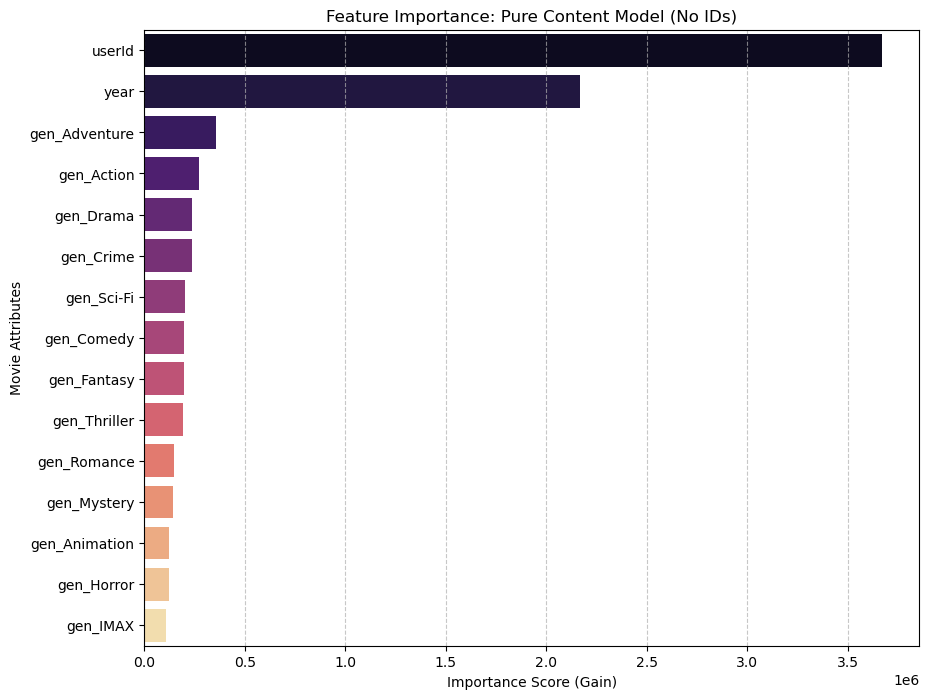

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importance from your newly trained 'model'
# 'gain' is usually better than 'split' because it shows the actual contribution to accuracy
importance_df = pd.DataFrame({
    'feature': X_train_content.columns,
    'importance': model.feature_importance(importance_type='gain')
})

# 2. Sort by importance and take the top 15
importance_df = importance_df.sort_values(by='importance', ascending=False).head(15)

# 3. Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='magma')

plt.title('Feature Importance: Pure Content Model (No IDs)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Movie Attributes')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
def get_recommendations_hybrid(user_id, model, interactions_df, movies_features_df, top_n=10):
    # 1. Find movies the user has already interacted with
    seen_movies = interactions_df[interactions_df['userId'] == user_id]['movieId'].unique()
    
    # 2. Get a list of all available movies in the catalog
    all_movies = movies_features_df['movieId'].unique()
    
    # 3. Filter out the seen movies to get candidates
    unseen_movies = list(set(all_movies) - set(seen_movies))
    
    # 4. Create a DataFrame for the candidates
    candidates = pd.DataFrame({'movieId': unseen_movies})
    
    # Assign the current user_id to all candidate rows
    candidates['userId'] = user_id
    
    # 5. Merge with movie attributes (year, genres)
    candidates = candidates.merge(movies_features_df, on='movieId', how='left')
    
    # Ensure categorical types are preserved for LightGBM
    candidates['userId'] = candidates['userId'].astype('category')
    
    # 6. Prepare features for prediction
    # CRITICAL: Drop 'movieId' because our hybrid model wasn't trained on it!
    features_to_predict = [col for col in candidates.columns if col not in ['movieId']]
    X_pred = candidates[features_to_predict]
    
    # 7. Generate probability scores
    candidates['prediction_score'] = model.predict(X_pred)
    
    # 8. Sort movies by score in descending order and select Top-N
    top_recs = candidates.sort_values(by='prediction_score', ascending=False).head(top_n)
    
    # Return the movie IDs and their scores
    return top_recs[['movieId', 'prediction_score']]

In [7]:
print("Generating recommendations...")
recs = get_recommendations_hybrid(user_id=31139, 
                                  model=model,
                                  interactions_df=df, 
                                  movies_features_df=movies_features, 
                                  top_n=5)
display(recs)

Generating recommendations...


,movieId,prediction_score
322,356,0.829741
265,296,0.765978
329,364,0.763744
527,595,0.742659
1020,1206,0.735270


In [8]:
movies = pd.read_csv('../data/preprocessed/movies_cleaned.csv')

In [9]:
recs.merge(movies, how='left', on='movieId')[['title', 'prediction_score']]

,title,prediction_score
0,Forrest Gump (1994),0.829741
1,Pulp Fiction (1994),0.765978
2,"Lion King, The (1994)",0.763744
3,Beauty and the Beast (1991),0.742659
4,"Clockwork Orange, A (1971)",0.735270


In [10]:
df[(df['userId']==31139)&(df['target']==1)].merge(movies, how='left', on='movieId')[['userId', 'title']]

,userId,title
0,31139,Rebel Without a Cause (1955)
1,31139,Addams Family Values (1993)
2,31139,In the Line of Fire (1993)
3,31139,Beauty of the Day (Belle de jour) (1967)
4,31139,True Romance (1993)
5,31139,Casablanca (1942)
6,31139,Bonnie and Clyde (1967)
7,31139,Clear and Present Danger (1994)
8,31139,Dial M for Murder (1954)
9,31139,Exotica (1994)


## Hyperparameter tuning

In [14]:
import optuna
import lightgbm as lgb
import warnings

# Disable unnecessary warning spam
warnings.filterwarnings('ignore') 

# Define features (excluding movieId for the hybrid approach)
features_hybrid = [col for col in X.columns if col != 'movieId']

dtrain_optuna = lgb.Dataset(X[features_hybrid], label=y)

# Define the objective function for Optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_jobs': 4,                  # Limit threads to prevent deadlocks
        'feature_pre_filter': False,  # Fixes the min_data_in_leaf dynamic change error
        
        # FIXED PARAMETERS (To save tuning time) 
        'max_depth': 8,              
        'min_data_in_leaf': 100,     
        'feature_fraction': 0.8,     
        
        # PARAMETERS TO TUNE (Only the core ones) 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 64)
    }
    
    # Run 3-fold cross-validation
    cv_results = lgb.cv(
        params,
        dtrain_optuna,
        num_boost_round=300, 
        nfold=3,
        stratified=True,
        # Stop early if the model doesn't improve for 15 rounds
        callbacks=[lgb.early_stopping(stopping_rounds=15)], 
        seed=42
    )
    
    return cv_results['valid auc-mean'][-1]

# Start the optimization process
print("Starting fast Optuna search on the FULL dataset (this may take a while)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) 

print("\nOPTIMIZATION COMPLETED")
print(f"Best AUC: {study.best_value:.4f}")
print("Best Params:", study.best_params)

[I 2026-05-04 11:40:22,141] A new study created in memory with name: no-name-c83738d7-a91a-4a58-9726-d5db0e7af363


Starting fast Optuna search on the FULL dataset (this may take a while)...
Training until validation scores don't improve for 15 rounds


[I 2026-05-04 11:41:55,159] Trial 0 finished with value: 0.8019796523246457 and parameters: {'learning_rate': 0.025172129913590587, 'num_leaves': 32}. Best is trial 0 with value: 0.8019796523246457.


Did not meet early stopping. Best iteration is:
[300]	valid's auc: 0.80198 + 0.000269596
Training until validation scores don't improve for 15 rounds


[I 2026-05-04 11:43:31,163] Trial 1 finished with value: 0.7923434170614224 and parameters: {'learning_rate': 0.013571134963635297, 'num_leaves': 41}. Best is trial 0 with value: 0.8019796523246457.


...

Did not meet early stopping. Best iteration is:
[300]	valid's auc: 0.803779 + 0.000878881
Training until validation scores don't improve for 15 rounds


[I 2026-05-04 11:54:15,647] Trial 8 finished with value: 0.8089278386567805 and parameters: {'learning_rate': 0.027115379113456104, 'num_leaves': 41}. Best is trial 8 with value: 0.8089278386567805.


Did not meet early stopping. Best iteration is:
[300]	valid's auc: 0.808928 + 0.000761697
Training until validation scores don't improve for 15 rounds


[I 2026-05-04 11:56:05,683] Trial 9 finished with value: 0.793087407430086 and parameters: {'learning_rate': 0.015322039088127069, 'num_leaves': 37}. Best is trial 8 with value: 0.8089278386567805.


Did not meet early stopping. Best iteration is:
[300]	valid's auc: 0.793087 + 0.000675773

OPTIMIZATION COMPLETED
Best AUC: 0.8089
Best Params: {'learning_rate': 0.027115379113456104, 'num_leaves': 41}


In [16]:
import lightgbm as lgb
import pandas as pd

print("Training the FINAL production model...")

#Define the features (excluding movieId)
features_hybrid = [col for col in X.columns if col != 'movieId']

dtrain_final = lgb.Dataset(X[features_hybrid], label=y)

# Combine fixed parameters with newly found optimal parameters
final_params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'n_jobs': -1,                  # Use all CPU cores
    'feature_pre_filter': False,
    
    # Fixed parameters we used during the search 
    'max_depth': 8,              
    'min_data_in_leaf': 100,     
    'feature_fraction': 0.8,
    
    # Optuna best params
    'learning_rate': 0.027115379113456104,
    'num_leaves': 41
}

# Train the model
# We use 300 rounds because CV stopped around iteration 300
final_model = lgb.train(
    params=final_params,
    train_set=dtrain_final,
    num_boost_round=300
)

# 5. Save the model
final_model.save_model('../models/lightgbm_hybrid_final.txt')

print("Final model trained and saved successfully!")

Training the FINAL production model...
Final model trained and saved successfully!


In [19]:
# Load the saved model from disk
print("Loading the production model from disk...")
production_model = lgb.Booster(model_file='../models/lightgbm_hybrid_final.txt')

# Define the user we want to test
target_user = 31139
print(f"Generating Top-5 recommendations for User #{target_user}...")

# Call our recommendation function
top_recs = get_recommendations_hybrid(
    user_id=target_user, 
    model=production_model, 
    interactions_df=df,                 # interactions dataframe
    movies_features_df=movies_features, # encoded features dataframe
    top_n=5
)

# Merge with the original 'movies' dataframe to get actual titles
# Assuming your EDA 'movies' dataframe has 'movieId' and 'title' columns
final_output = top_recs.merge(movies[['movieId', 'title']], on='movieId', how='left')

print("\nFINAL RECOMMENDATIONS")
display(final_output[['title', 'prediction_score']])

Loading the production model from disk...
Generating Top-5 recommendations for User #31139...

FINAL RECOMMENDATIONS


,title,prediction_score
0,"Lion King, The (1994)",0.797565
1,Beauty and the Beast (1991),0.709258
2,Forrest Gump (1994),0.693824
3,Star Wars: Episode IV - A New Hope (1977),0.617180
4,Rob Roy (1995),0.590991
